Real counts: {'.jpg': 41150, '.obj': 27434, '.mtl': 13717, '.png': 27434}
Fake counts: {'.jpg': 24462, '.obj': 16308, '.mtl': 8154, '.png': 16308}
Total counts: {'.jpg': 65612, '.png': 43742, '.obj': 43742, '.mtl': 21871}


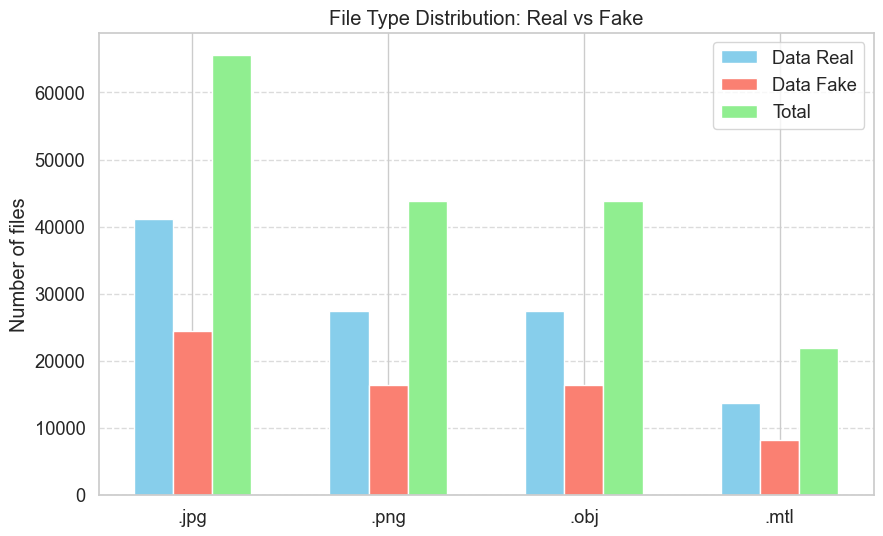

In [11]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_PATH_REAL = "D://DATA_ROOT//REAL"
DATA_PATHS_FAKE = [
    "D://DATA_ROOT//render_3d",
    "D://DATA_ROOT//FAKE_RENDER"
]

file_types = ['.jpg', '.png', '.obj', '.mtl']

def count_file_types(root_paths, types=file_types):
    """
    Đếm số lượng file theo từng loại trong nhiều folder gốc
    """
    counts = defaultdict(int)
    
    for root_path in root_paths:
        if not os.path.exists(root_path):
            continue
        for dirpath, dirnames, filenames in os.walk(root_path):
            for f in filenames:
                ext = os.path.splitext(f)[1].lower()
                if ext in types:
                    counts[ext] += 1
    return counts

real_counts = count_file_types([DATA_PATH_REAL])
fake_counts = count_file_types(DATA_PATHS_FAKE)

total_counts = {ext: real_counts.get(ext,0) + fake_counts.get(ext,0) for ext in file_types}

print("Real counts:", dict(real_counts))
print("Fake counts:", dict(fake_counts))
print("Total counts:", total_counts)

x = range(len(file_types))
plt.figure(figsize=(10,6))

plt.bar([i-0.2 for i in x], [real_counts.get(ext,0) for ext in file_types], width=0.2, label='Data Real', color='skyblue')
plt.bar(x, [fake_counts.get(ext,0) for ext in file_types], width=0.2, label='Data Fake', color='salmon')
plt.bar([i+0.2 for i in x], [total_counts.get(ext,0) for ext in file_types], width=0.2, label='Total', color='lightgreen')

plt.xticks(x, file_types)
plt.ylabel('Number of files')
plt.title('File Type Distribution: Real vs Fake')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from math import pi

sns.set(style="whitegrid", font_scale=1.2)

# Load JSON file
json_path = r"E:\attend3d_model_ai\logs\experiments\3d_face_20251127_173936\training_log.json"

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

epochs = np.array([e["epoch"] for e in data["epochs"]])

# Extract metrics
train_loss = np.array([e["train"]["loss"] for e in data["epochs"]])
val_loss   = np.array([e["validation"]["loss"] for e in data["epochs"]])

train_acc = np.array([e["train"]["cls_acc"] for e in data["epochs"]])
val_acc   = np.array([e["validation"]["cls_acc"] for e in data["epochs"]])

train_auc = np.array([e["train"]["spoof_metrics"]["auc"] for e in data["epochs"]])
val_auc   = np.array([e["validation"]["spoof_metrics"]["auc"] for e in data["epochs"]])

train_f1 = np.array([e["train"]["spoof_metrics"]["f1"] for e in data["epochs"]])
val_f1   = np.array([e["validation"]["spoof_metrics"]["f1"] for e in data["epochs"]])

train_eer = np.array([e["train"]["spoof_metrics"]["eer"] for e in data["epochs"]])
val_eer   = np.array([e["validation"]["spoof_metrics"]["eer"] for e in data["epochs"]])

train_apcer = np.array([e["train"]["spoof_metrics"]["apcer"] for e in data["epochs"]])
val_apcer   = np.array([e["validation"]["spoof_metrics"]["apcer"] for e in data["epochs"]])

train_bpcer = np.array([e["train"]["spoof_metrics"]["bpcer"] for e in data["epochs"]])
val_bpcer   = np.array([e["validation"]["spoof_metrics"]["bpcer"] for e in data["epochs"]])

spoof_loss  = np.array([e["train"]["spoof_loss"] for e in data["epochs"]])
depth_loss  = np.array([e["train"]["depth_loss"] for e in data["epochs"]])
center_loss = np.array([e["train"]["center_loss"] for e in data["epochs"]])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6456\128415947.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[3].boxplot([train_acc, val_acc], labels=["Train", "Validation"])


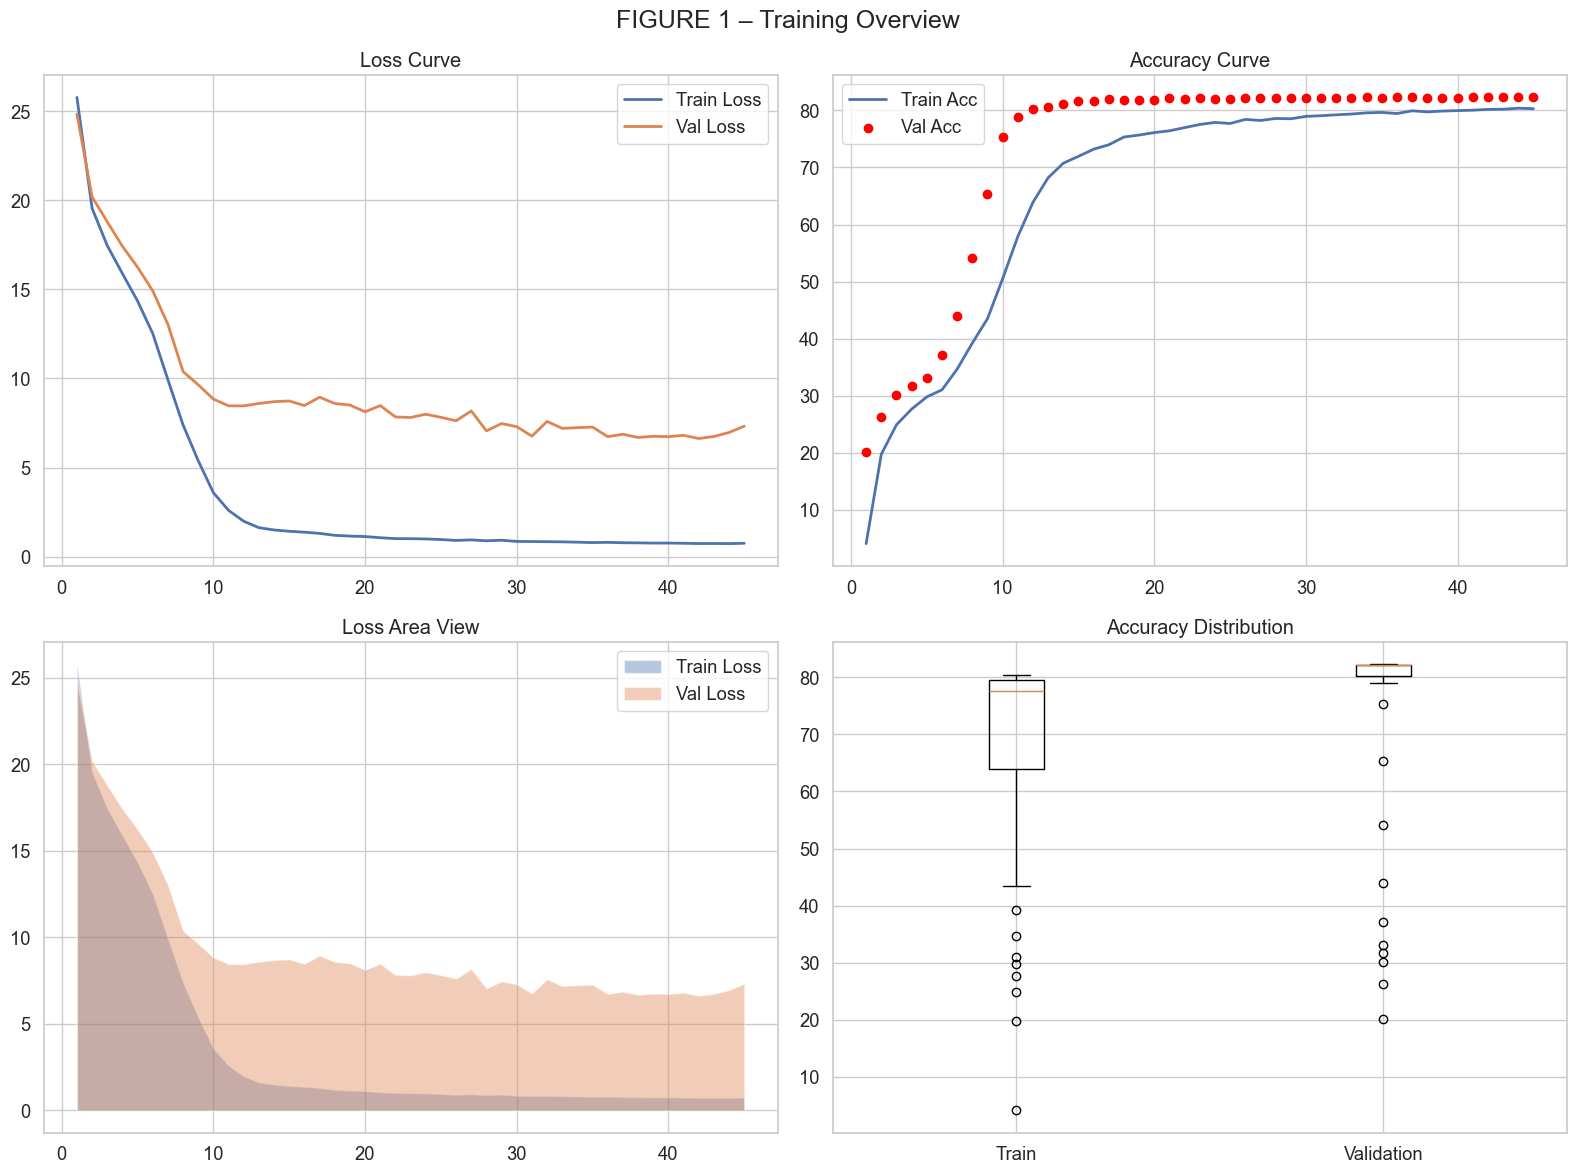

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1. Loss line plot
axes[0].plot(epochs, train_loss, label="Train Loss", linewidth=2)
axes[0].plot(epochs, val_loss, label="Val Loss", linewidth=2)
axes[0].set_title("Loss Curve")
axes[0].legend()

# 2. Accuracy scatter + line
axes[1].plot(epochs, train_acc, label="Train Acc", linewidth=2)
axes[1].scatter(epochs, val_acc, label="Val Acc", color="red")
axes[1].set_title("Accuracy Curve")
axes[1].legend()

# 3. Loss area plot
axes[2].fill_between(epochs, train_loss, alpha=0.4, label="Train Loss")
axes[2].fill_between(epochs, val_loss, alpha=0.4, label="Val Loss")
axes[2].set_title("Loss Area View")
axes[2].legend()

# 4. Accuracy distribution boxplot
axes[3].boxplot([train_acc, val_acc], labels=["Train", "Validation"])
axes[3].set_title("Accuracy Distribution")

plt.suptitle("FIGURE 1 – Training Overview", fontsize=18)
plt.tight_layout()
plt.show()

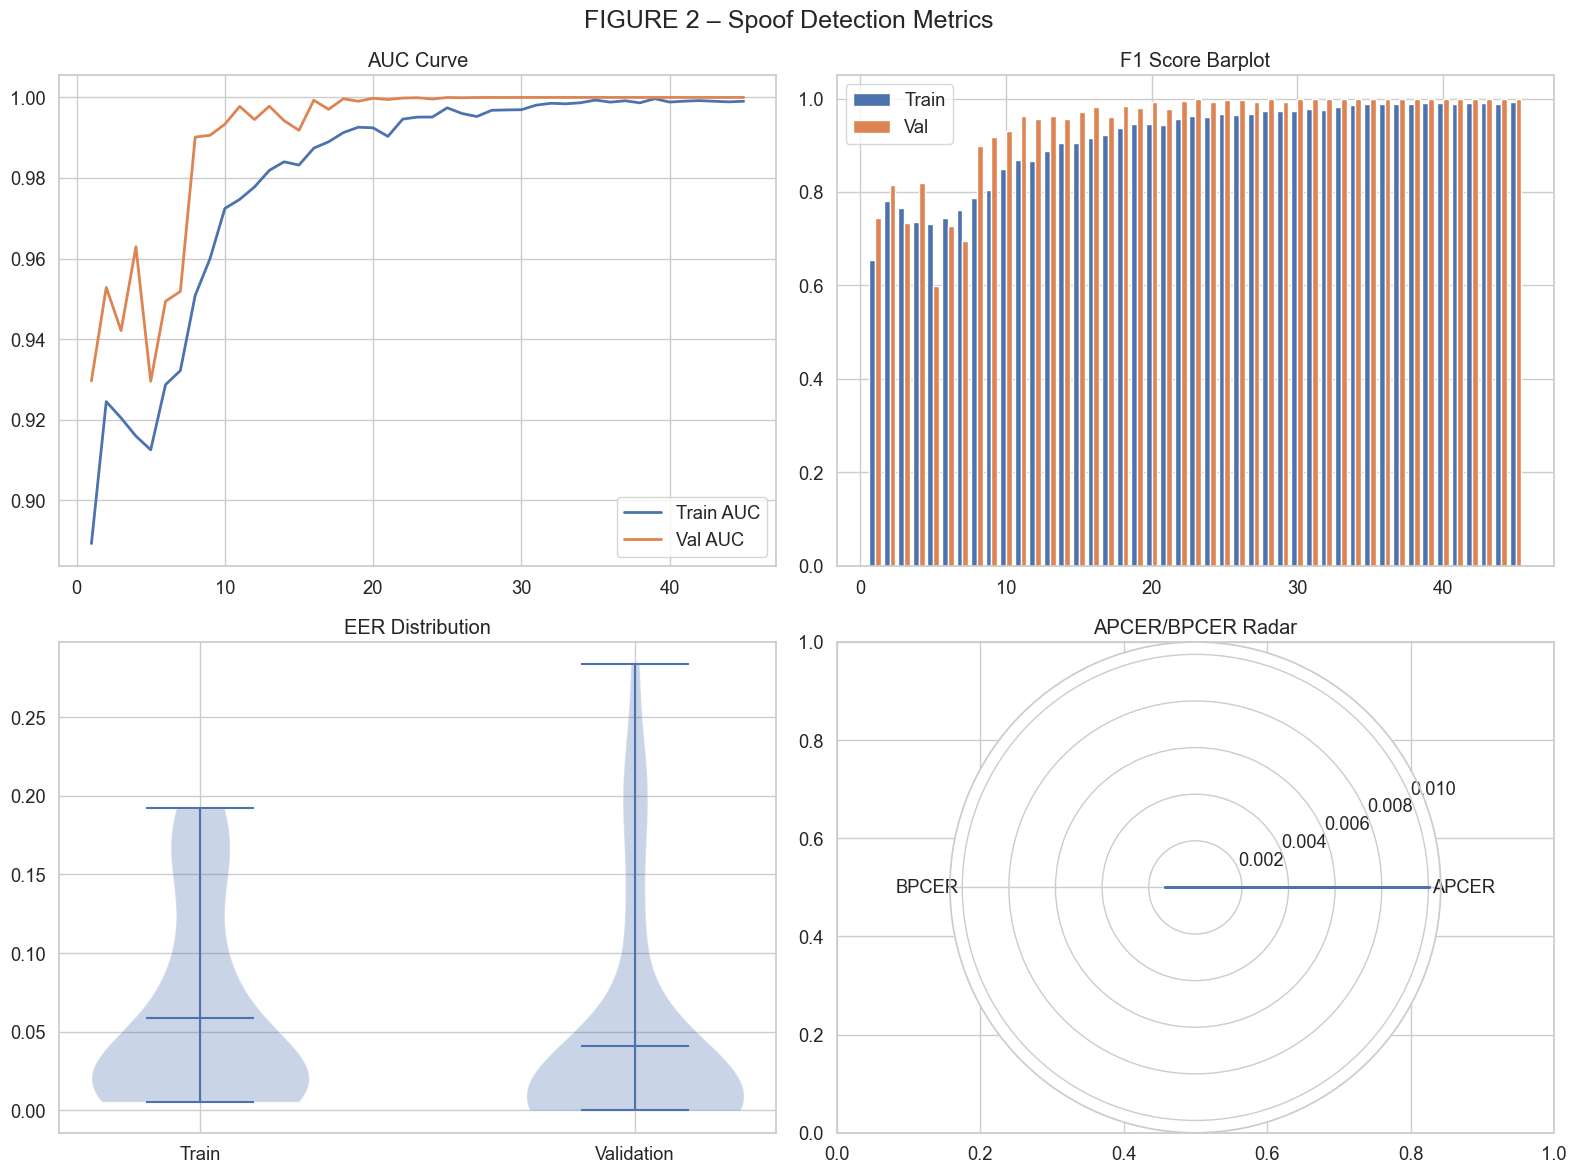

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# 1 — AUC line plot
axes[0].plot(epochs, train_auc, label="Train AUC", linewidth=2)
axes[0].plot(epochs, val_auc, label="Val AUC", linewidth=2)
axes[0].set_title("AUC Curve")
axes[0].legend()

# 2 — F1 bar plot
axes[1].bar(epochs - 0.2, train_f1, width=0.4, label="Train")
axes[1].bar(epochs + 0.2, val_f1, width=0.4, label="Val")
axes[1].set_title("F1 Score Barplot")
axes[1].legend()

# 3 — EER violin
axes[2].violinplot([train_eer, val_eer], showmeans=True)
axes[2].set_xticks([1,2])
axes[2].set_xticklabels(["Train", "Validation"])
axes[2].set_title("EER Distribution")

# 4 — APCER/BPCER radar
metrics = ["APCER", "BPCER"]
train_vals = [train_apcer[-1], train_bpcer[-1]]
val_vals = [val_apcer[-1], val_bpcer[-1]]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
train_plot = train_vals + train_vals[:1]
val_plot = val_vals + val_vals[:1]

ax = plt.subplot(2,2,4, polar=True)
ax.plot(angles, train_plot, label="Train", linewidth=2)
ax.plot(angles, val_plot, label="Validation", linewidth=2)
ax.fill(angles, train_plot, alpha=0.2)
ax.fill(angles, val_plot, alpha=0.2)
plt.xticks(angles[:-1], metrics)
ax.set_title("APCER/BPCER Radar")

plt.suptitle("FIGURE 2 – Spoof Detection Metrics", fontsize=18)
plt.tight_layout()
plt.show()

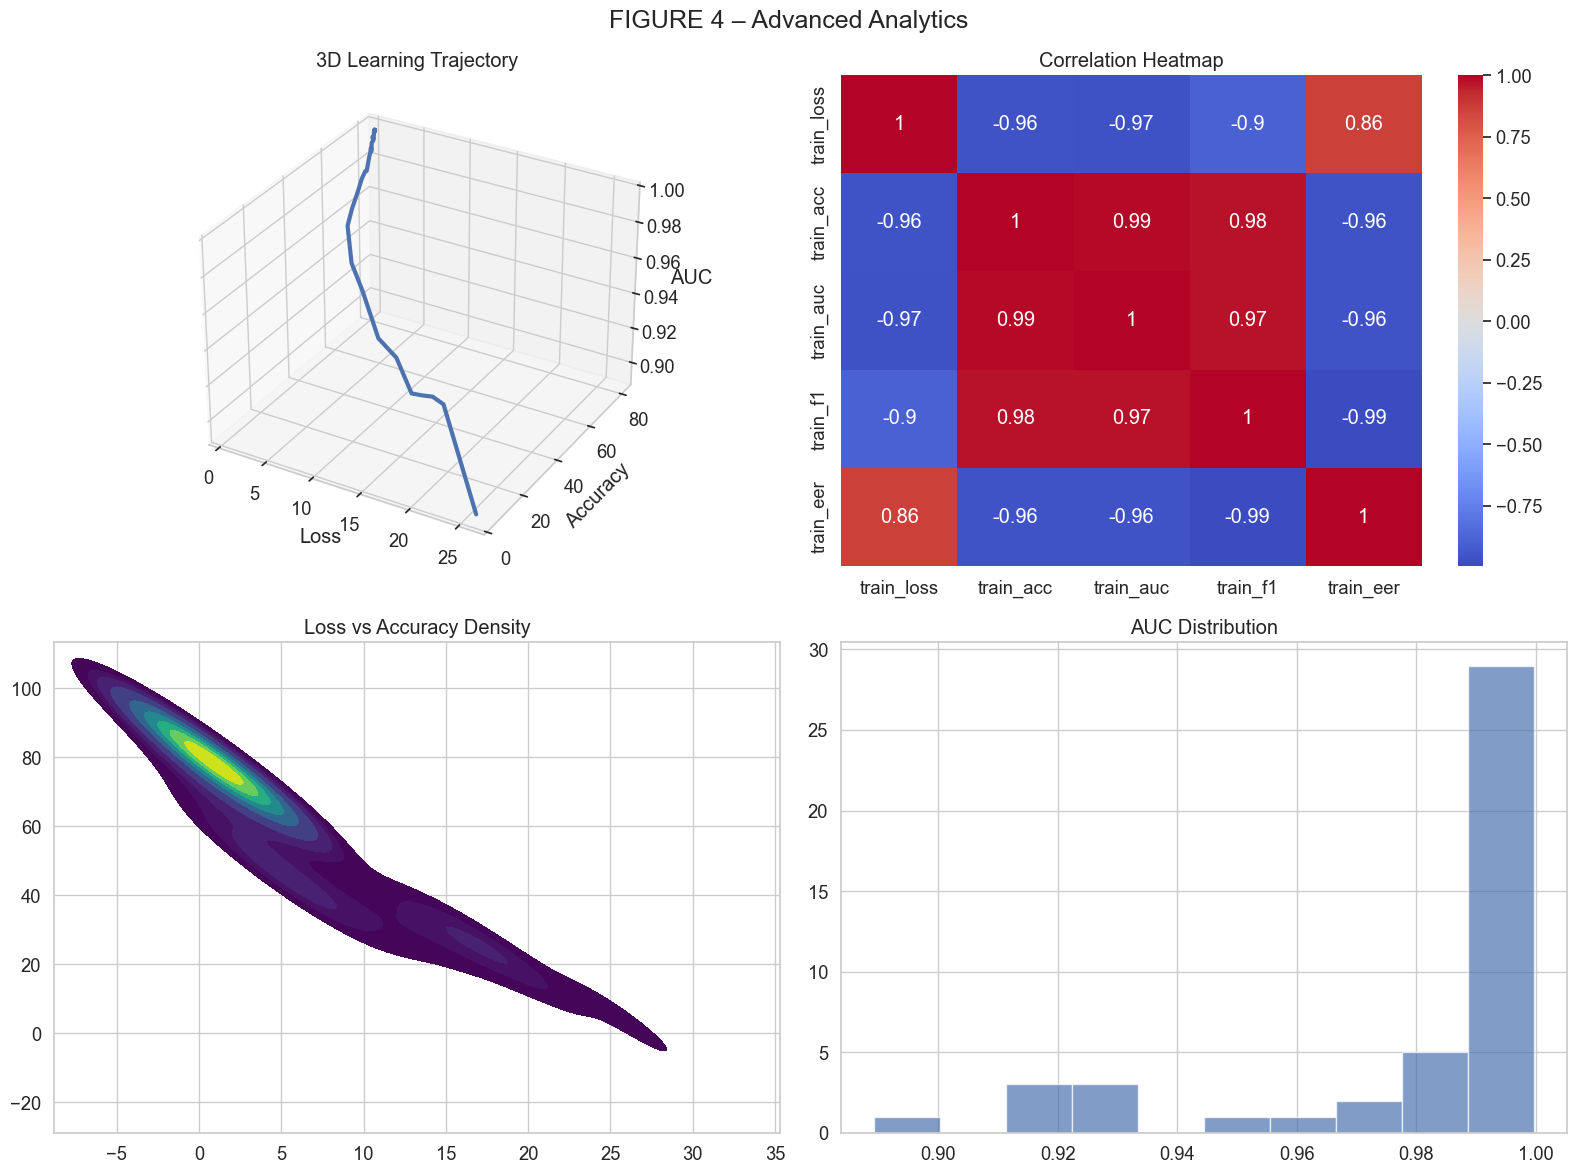

In [15]:
fig = plt.figure(figsize=(16, 12))

# 1 — 3D plot
ax = fig.add_subplot(2, 2, 1, projection="3d")
ax.plot(train_loss, train_acc, train_auc, linewidth=3)
ax.set_xlabel("Loss")
ax.set_ylabel("Accuracy")
ax.set_zlabel("AUC")
ax.set_title("3D Learning Trajectory")

# 2 — Heatmap
df = pd.DataFrame({
    "train_loss": train_loss,
    "train_acc": train_acc,
    "train_auc": train_auc,
    "train_f1": train_f1,
    "train_eer": train_eer
})
ax2 = fig.add_subplot(2,2,2)
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", ax=ax2)
ax2.set_title("Correlation Heatmap")

# 3 — KDE
ax3 = fig.add_subplot(2,2,3)
sns.kdeplot(x=train_loss, y=train_acc, fill=True, cmap="viridis", ax=ax3)
ax3.set_title("Loss vs Accuracy Density")

# 4 — Histogram
ax4 = fig.add_subplot(2,2,4)
ax4.hist(train_auc, bins=10, alpha=0.7, label="AUC")
ax4.set_title("AUC Distribution")

plt.suptitle("FIGURE 4 – Advanced Analytics", fontsize=18)
plt.tight_layout()
plt.show()